## Install Rmotifx

In [1]:
system("wget https://github.com/wangshisheng/motifeR/raw/refs/heads/master/ggseqlogo_0.1.tar.gz")
system("wget https://github.com/wangshisheng/motifeR/raw/refs/heads/master/rmotifx_1.0.tar.gz")

In [ ]:
install.packages("rmotifx_1.0.tar.gz", repos = NULL,type="source")
install.packages("ggseqlogo_0.1.tar.gz", repos = NULL,type="source")
install.packages("stringr")
install.packages("ggplot2")

## Import library

In [3]:
library(rmotifx)
library(ggseqlogo)
library(ggplot2)
library(readxl)
library(stringr)

In [4]:
system("git clone https://github.com/sou-06/Phospho_Logo_PD.git")

## Import fasta

"Glymax_uniprot_id.fasta"は大豆用UniprotのID

このFastaファイル名を使うデータに合わせて書き換える

シロイヌナズナ "Araport11_genes.201606.pep.fasta"

イネ "Osativa_204_v7.0.protein.fasta"


In [14]:
setwd("/content/Phospho_Logo_PD")
fas <- scan("/content/Phospho_Logo_PD/Osativa_204_v7.0.protein.fasta", what = character(), na.strings = "zzz" , sep = "\n")
genenames = fas[str_sub(fas, start = 1, end = 1) == ">"]
genes = data.frame(name = str_sub(genenames,start = 2,end = 12))
genes$anotation = str_sub(genenames,start = 2,end = -1)
genes$name <- trimws(sapply(strsplit(genes$anotation, "[| ,]+"), `[`, 1))
fas[str_sub(fas, start = 1, end = 1) == ">"] = " "
allseq = paste(fas,sep = "",collapse = "")
seqs = str_split(allseq, " ")[[1]]
seqs <- seqs[2:length(seqs)]
genes$seq <- seqs

## Upload xlsx file from PD

←🗀️（フォルダ）のマークをクリックし出てきたアイコンの一番左、ファイルのアップロードを押して、エクセルファイルをアップロード

連続で、複数のファイルを処理したい場合は、ここから繰り返す。


## Read xlsx file

先ほどアップロードしたファイルを←の中で探して、右クリックしてCopy path

read_xlsx に指定するファイル名の部分を消して、張り付け。

In [15]:
setwd("/content")
dataA <- read_xlsx("/content/test.xlsx", sheet = "Filterd")

In [ ]:
seqLength = 6 #取り出す配列の長さ
seqs = rep("", nrow(dataA) * 2)
modPos <- dataA$`Modifications in Master Proteins`
dataA$motif <- ""
out <- out.file <- file("motifs.txt", open = "w")
phosp <- regexpr("xPhospho", modPos)
l = 0
r = 0
cnt = 1
for (i in 1:nrow(dataA)) {
    mod_in_protein = modPos[i]
    if (is.na(phosp[i])) {
        next #writeLines("", out.file)
        }
    else {
        geneName = strsplit(mod_in_protein, " ")[[1]][1]
        seq <- genes$seq[genes$name == geneName]
        mods = mod_in_protein
        substr1 <- str_sub(mods,start = phosp[i] + 9,end = -1)
        if(identical(seq, character(0))) next

        for (j in 1:str_length(substr1)) {
            if (str_sub(substr1, j, j) == "[") {
                l = j + 1
            } else if (str_sub(substr1, start = j, end = j) =="]") {
                r = j - 1
                break
            }
        }
        if (length(seq) > 1) seq = seq[1]
        poss = str_split(str_sub(substr1,start= l,end = r), "; ")[[1]]

        pep2 = ""
        t = i
        match = regexpr("(S|T|Y)[0-9]+", poss)
        for (i in 1:length(poss)) {
            #print(match[i])
            if (match[i] < 1) next
            num1 <- str_sub(poss[i], start = match[i] + 1, end = match[i] + attr(match,"match.length")[i] - 1)
            num = as.integer(num1)
            if (num - seqLength < 1 || num + seqLength > str_length(seq) ) next
            pep = substr(seq, num - seqLength, num + seqLength)
            seqs[cnt] = pep
            pep2 = paste(pep2, pep, sep = " ")
            cnt = cnt + 1
        }
        dataA$motif[t] <- pep2
    }
}

seqs = seqs[str_length(seqs) > seqLength * 2]
seqs[1:3]

バックグラウンドファイルの読み込み。Fastaファイルに含まれる全タンパク質のセリン、スレオニンと前後6残基の配列を取り出している。

BG_〇〇.txtのようなファイル名で保存されている。

←の中でPhospho_Logo_PDの中で使う植物種を探して、右クリックしてCopy path

In [28]:
bg.path <- "/content/Phospho_Logo_PD/BG_Osativa.txt"
fg.seqs <- seqs
bg.seqs <- readLines(bg.path)
mot <- motifx(fg.seqs, bg.seqs, central.res = 'STY', min.seqs = 14, pval.cutoff = 1e-5)

In [ ]:
mot

In [30]:
write.csv(mot$df, file = "summary.csv")

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the ggseqlogo package.
  Please report the issue at <https://github.com/omarwagih/ggseqlogo/issues>.”


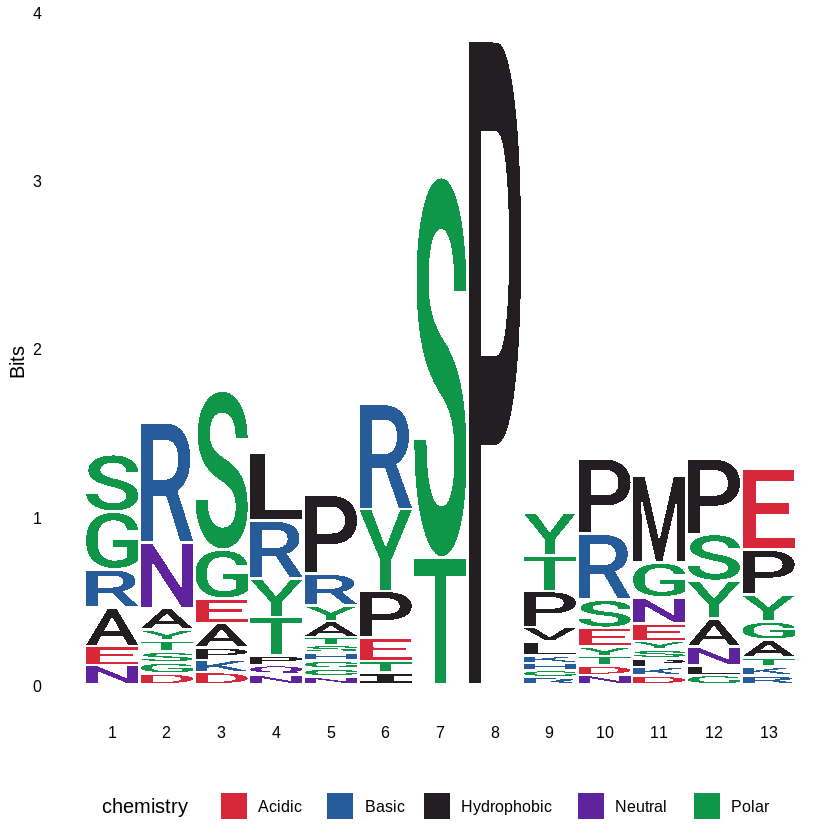

In [31]:
p <- ggplot() # 空のキャンバスを作成。ここに要素を足していく
p <- p + geom_logo(mot$motiflist[[1]]$pos) #[[1]]の中身を変えることで、何番目のロゴを出すかを変更可能
p <- p + theme_logo()
plot(p)
ggsave("Logo.svg", width = 24, height = 8,device = grDevices::svg)
ggsave("Logo.png", width = 24, height = 8)

## 配列の抽出と編集したFourGroundのデータからのロゴの出力

出力した配列情報をまとめるなどの編集をしたい場合はこちら。

In [42]:
seq_list = mot$motiflist[[1]]$pos #[[1]]の中身を変えることで、何番目のロゴの内容を出すか変更可能
print(seq_list)
write(seq_list, file = "motif1_seqlist.txt")

 [1] "EDDNCPTPRTPAE" "AAETAESPTENNA" "NNATYPSPLSESE" "ESKLNTSPVNNAT"
 [5] "NNATYPSPLSESE" "RRGRPRTPTPGSY" "GNSYRRSPPPMYP" "GNSYRRSPPPMYP"
 [9] "SRSLPYSPYRMPE" "RRGRPRTPTPGSY" "RGGRGYSPHRSPP" "GYSPHRSPPYGGG"
[13] "SRSLPYSPYRMPE" "AAETAESPTENNA" "GNSYRRSPPPMYP" "RRGRPRTPTPGSY"
[17] "GRPRTPTPGSYLG" "GNSYRRSPPPMYP" "SRSLPYSPYRMPE" "SRSLPYSPYRMPE"
[21] "ARSQSRSPVPDPR" "ATSRPITPKDKAK" "SRSLPYSPYRMPE" "SRSLPYSPYRMPE"


motif_seqlist.txtをダウンロードして、編集することが可能。

続いて、編集したファイルを再度アップロードして、

←左のファイルリストの中から探し出し、右クリックでパスをコピーする。コピーしたパスを

inputfile <-read("〇〇.txt")の部分に張り付けて上書きする。

その後、下のセルを実行。

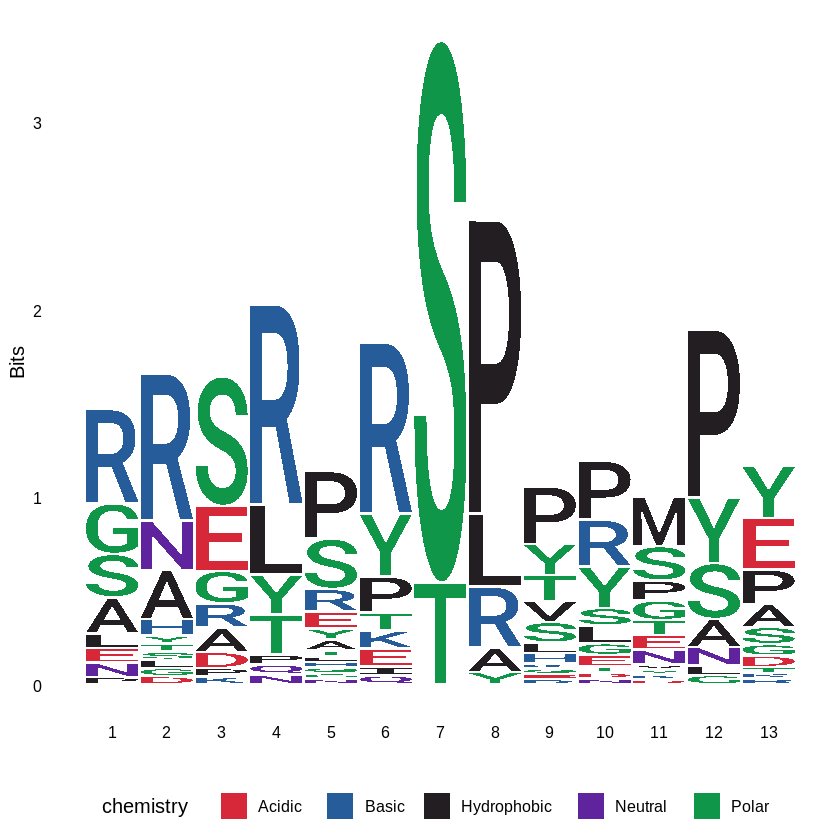

In [51]:
inputfile <- read.table("motif2_seqlist.txt",header = FALSE)

p <- ggplot() # 空のキャンバスを作成。ここに要素を足していく
p <- p + geom_logo(inputfile)
p <- p + theme_logo()
plot(p)
ggsave("Logo.svg", width = 24, height = 8,device = grDevices::svg)
ggsave("Logo.png", width = 24, height = 8)